In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np

%matplotlib inline

In [2]:
X, y = make_blobs(n_samples=1000, centers=3, n_features=2)

In [3]:
X

array([[  9.26961725, -10.00180143],
       [ 10.64084974, -10.23701168],
       [ -2.97085957,   4.44920128],
       ...,
       [ -2.28373254,   5.08443437],
       [  8.03733195, -12.60023937],
       [ 11.25042948,  -9.27440495]], shape=(1000, 2))

In [4]:
y

array([0, 0, 1, 2, 1, 1, 1, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 2,
       2, 2, 0, 0, 0, 0, 0, 2, 1, 0, 2, 0, 1, 0, 0, 2, 1, 0, 2, 1, 0, 0,
       1, 0, 2, 2, 1, 0, 2, 0, 2, 2, 0, 1, 1, 1, 0, 2, 1, 2, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 2, 1, 1, 0, 2, 1, 1, 0, 0, 2, 0, 2, 0, 0,
       0, 2, 1, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 0, 2, 1, 1,
       1, 0, 0, 2, 1, 2, 1, 2, 1, 2, 2, 1, 2, 1, 2, 0, 2, 0, 0, 1, 1, 1,
       2, 0, 1, 1, 1, 0, 1, 0, 0, 2, 1, 1, 2, 1, 1, 2, 1, 0, 2, 2, 0, 2,
       0, 0, 0, 2, 0, 0, 2, 2, 1, 0, 0, 0, 0, 1, 2, 0, 1, 1, 0, 2, 0, 0,
       2, 1, 0, 1, 2, 1, 1, 2, 0, 2, 2, 0, 0, 2, 0, 1, 2, 1, 2, 2, 2, 2,
       0, 1, 2, 1, 2, 2, 1, 1, 0, 1, 2, 2, 1, 1, 0, 0, 0, 0, 2, 2, 0, 2,
       0, 2, 0, 0, 2, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 2, 1, 0, 2, 0, 0, 0,
       2, 0, 2, 0, 0, 2, 1, 2, 1, 2, 2, 0, 1, 1, 2, 1, 2, 2, 2, 2, 0, 2,
       1, 0, 2, 1, 2, 1, 0, 2, 0, 0, 0, 1, 2, 1, 2, 0, 2, 2, 0, 2, 2, 1,
       2, 2, 1, 1, 0, 0, 0, 2, 2, 2, 2, 2, 1, 2, 2,

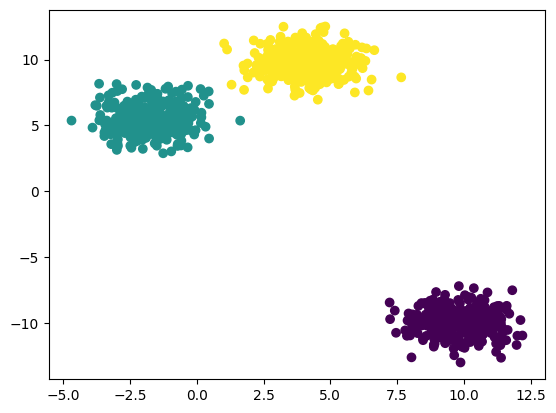

In [5]:
plt.scatter(X[:, 0], X[:, 1], c=y)

In [6]:
# standardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [9]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
from sklearn.cluster import KMeans

In [11]:
## Elbow method To select K Value
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [12]:
wcss

[1340.000000000001,
 227.03425932516956,
 36.22770522870822,
 29.210672227897298,
 23.815374746240426,
 18.211056196845707,
 16.910694598990784,
 15.33053919714989,
 14.440805548542318,
 13.301140396015564]

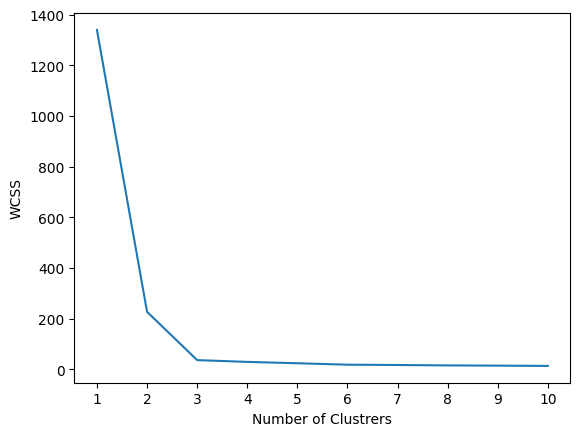

In [13]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [14]:
kmeans = KMeans(n_clusters=3, init="k-means++")

In [15]:
kmeans.fit_predict(X_train_scaled)

array([1, 2, 2, 2, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       2, 0, 0, 1, 2, 1, 0, 2, 0, 1, 1, 1, 0, 0, 2, 1, 0, 1, 0, 0, 0, 2,
       1, 1, 0, 1, 2, 1, 2, 1, 2, 2, 0, 0, 2, 2, 0, 0, 2, 1, 2, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 2, 2, 1, 0, 1, 0, 2, 1, 1, 1, 1, 2, 0, 2, 1,
       2, 2, 2, 0, 1, 2, 1, 2, 2, 2, 1, 0, 1, 2, 2, 1, 2, 0, 1, 2, 2, 0,
       0, 1, 2, 2, 2, 0, 2, 2, 2, 2, 0, 1, 2, 0, 1, 0, 1, 2, 2, 1, 2, 2,
       2, 1, 0, 1, 1, 0, 0, 1, 2, 2, 0, 2, 1, 2, 0, 0, 1, 0, 0, 2, 0, 1,
       1, 0, 0, 0, 1, 1, 2, 2, 2, 1, 0, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 2,
       2, 1, 2, 2, 1, 0, 1, 0, 1, 1, 0, 1, 1, 2, 2, 2, 1, 2, 2, 2, 2, 2,
       1, 2, 0, 1, 2, 2, 0, 0, 2, 1, 1, 1, 0, 2, 1, 0, 2, 2, 0, 0, 1, 2,
       1, 0, 1, 1, 0, 1, 0, 2, 2, 1, 2, 0, 1, 1, 2, 0, 0, 2, 2, 2, 0, 2,
       2, 2, 2, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 2, 2, 1, 1, 0, 0, 2, 2, 0,
       0, 0, 2, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 2, 2, 0, 2, 1, 1, 2, 2, 1,
       2, 0, 1, 0, 2, 2, 2, 1, 0, 0, 1, 1, 2, 0, 0,

In [16]:
y_pred = kmeans.predict(X_test_scaled)

In [17]:
y_pred

array([2, 2, 0, 2, 1, 2, 1, 2, 0, 1, 0, 1, 1, 1, 2, 0, 2, 2, 1, 1, 1, 0,
       2, 0, 1, 2, 1, 1, 1, 2, 0, 0, 1, 1, 0, 0, 0, 2, 2, 2, 0, 1, 0, 0,
       2, 1, 0, 0, 1, 2, 0, 1, 2, 1, 2, 1, 2, 2, 2, 0, 2, 0, 2, 2, 1, 1,
       1, 1, 1, 0, 2, 2, 0, 0, 0, 1, 1, 0, 2, 2, 1, 1, 1, 1, 2, 1, 0, 2,
       2, 1, 2, 0, 1, 0, 0, 2, 1, 0, 1, 1, 1, 0, 2, 2, 0, 2, 2, 0, 2, 0,
       2, 1, 1, 1, 0, 0, 0, 0, 2, 2, 2, 0, 2, 2, 0, 0, 0, 2, 2, 1, 2, 1,
       0, 0, 1, 1, 2, 0, 0, 0, 1, 2, 0, 2, 1, 1, 0, 2, 2, 0, 0, 0, 0, 2,
       0, 1, 1, 2, 1, 0, 1, 0, 0, 2, 1, 2, 1, 2, 1, 1, 2, 1, 1, 2, 2, 1,
       1, 2, 1, 0, 1, 2, 2, 0, 2, 0, 0, 1, 0, 1, 1, 2, 1, 1, 0, 1, 0, 2,
       2, 2, 2, 0, 0, 2, 0, 2, 0, 1, 1, 1, 0, 2, 2, 0, 1, 1, 1, 2, 0, 2,
       2, 1, 2, 0, 0, 1, 0, 2, 1, 2, 0, 2, 0, 2, 0, 0, 1, 2, 2, 1, 2, 1,
       0, 1, 0, 1, 2, 0, 0, 2, 0, 1, 1, 0, 2, 1, 0, 1, 1, 1, 2, 2, 1, 2,
       1, 0, 0, 2, 0, 2, 2, 1, 2, 1, 2, 0, 2, 2, 0, 2, 2, 1, 0, 0, 1, 2,
       0, 0, 1, 2, 2, 0, 0, 1, 0, 2, 1, 2, 0, 0, 0,

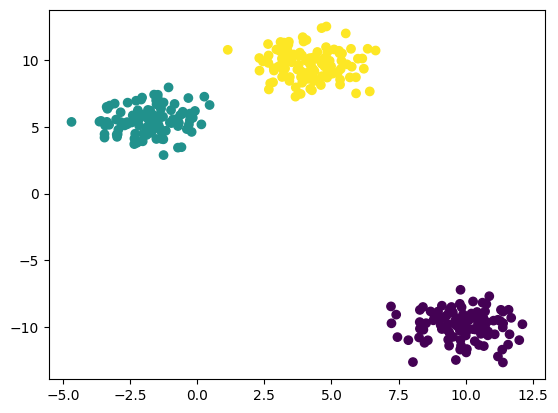

In [18]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred)

In [19]:
## Validating the k value
## kneelocator
## Silhoutee scoring

In [20]:
## kneelocator
!pip install kneed


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from kneed import KneeLocator

In [22]:
kl = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")

In [23]:
kl.elbow

np.int64(3)

In [24]:
## silhoutte score
from sklearn.metrics import silhouette_score

In [25]:
silhouette_coefficients = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_coefficients.append(score)

In [26]:
silhouette_coefficients

[0.7748021276107384,
 0.810468151765992,
 0.6715201642120711,
 0.5689796587330597,
 0.5561018051363633,
 0.3941574317079512,
 0.3683029400576344,
 0.34734653941855914,
 0.32445111865883186]

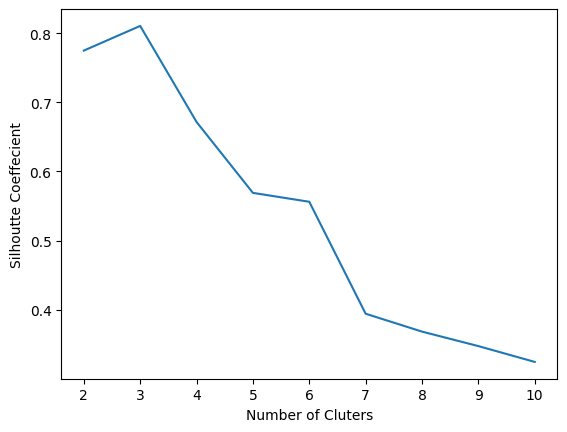

In [27]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()

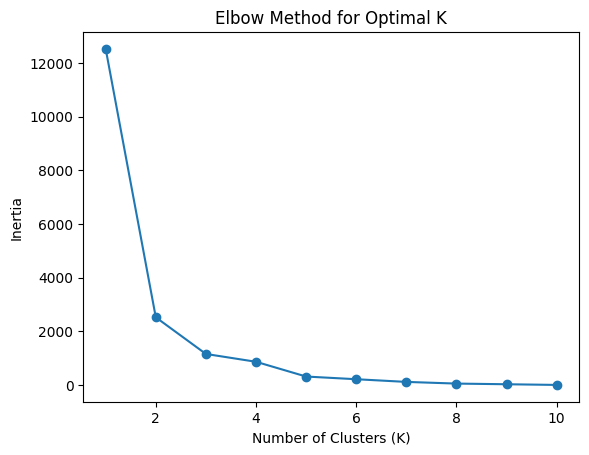

In [28]:
# ELBOW METHOD

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Example data (Annual Income vs Spending Score)
data = {'Income': [15, 80, 90, 25, 85, 60, 40, 70, 95, 35],
        'Spending': [30, 70, 80, 20, 75, 50, 40, 60, 90, 35]}
df = pd.DataFrame(data)

# Step 1: Try K from 1 to 10
inertia = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(df[['Income', 'Spending']])
    inertia.append(model.inertia_)

# Step 2: Plot
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()


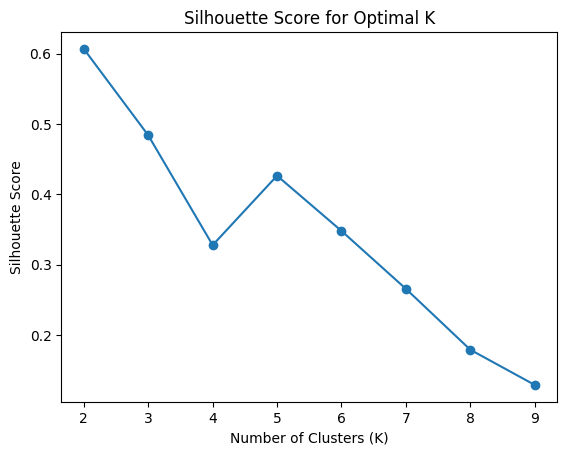

In [29]:
# SILHOUETTE SCORE

from sklearn.metrics import silhouette_score

scores = []
K = range(2, 10)  # start from 2 clusters
for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    preds = model.fit_predict(df[['Income', 'Spending']])
    score = silhouette_score(df[['Income', 'Spending']], preds)
    scores.append(score)

plt.plot(K, scores, marker='o')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.show()
